In [104]:
import jax.numpy as jnp
import numpy as np
import hj_reachability as hj
import matplotlib.pyplot as plt

# 2d Linear Oscillator Dynamics:


$$\dot{x} =
\begin{bmatrix}
\dot{x_1} \\
\dot{x_2}\\
\end{bmatrix}
=
\begin{bmatrix}
x_2\\
-w^2x_1 + u + d
\end{bmatrix}
$$

Control Jacobian:
$$\begin{bmatrix}
0\\
1\\
\end{bmatrix}$$

Disturbance Jacobian:
$$\begin{bmatrix}
0\\
1
\end{bmatrix}$$

HJI:
$$\frac{\partial V}{\partial t} + \max_d\min_u\nabla V^\top(f(x)+G(x)u+W(x)d) = 0$$
$$V(0, x) = g(x)$$

# Define 2d Linear Oscillator Dynamics

In [105]:
class LinearOscillator(hj.ControlAndDisturbanceAffineDynamics):
    def __init__(self, oscillation_speed, u_bound, d_bound, control_mode="min", disturbance_mode="max"):
        self.oscillation_speed = oscillation_speed

        control_space = hj.sets.Box(jnp.array([-u_bound]), jnp.array([u_bound]))
        disturbance_space = hj.sets.Box(jnp.array([-d_bound]), jnp.array([d_bound]))

        super().__init__(control_mode, disturbance_mode, control_space, disturbance_space)
    
    def open_loop_dynamics(self, state, time):
        x1, x2 = state 
        w = self.oscillation_speed
        return jnp.array([x2, -w**2 * x1])

    def control_jacobian(self, state, time):
        x1, x2 = state
        return jnp.array([[0], [1]])

    def disturbance_jacobian(self, state, time):
        return jnp.array([[0], [1]])

# Define time and grid discretization

In [106]:
time = -1.0 # time of simulation
time_discretization = 20

x1_discretization = 201
x2_discretization = 201

x1_grid = 1
x2_grid = 1

u_bound = 1.0
d_bound = 0.5
oscillation_speed = 1.0

# Instantiate grid and dynamics

In [107]:
times = np.linspace(0.0, time, time_discretization)
dynamics = LinearOscillator(oscillation_speed=oscillation_speed, u_bound=u_bound, d_bound=d_bound)
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(hj.sets.Box(np.array([-x1_grid, -x2_grid]),np.array([x1_grid, x2_grid]),), shape=(x1_discretization, x2_discretization))

# Create the target set

In [108]:
positions = grid.states[..., :2]
threshold = 0.25
values0 = jnp.linalg.norm(positions, axis=-1) - threshold 

# Choose solver, pick either backwards reachable set or backwards reachable tube

In [109]:
# for backwards reachable tube
solver_settings = hj.SolverSettings.with_accuracy("very_high", hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)

# Solve for the value function

In [110]:
value_function = hj.solve(solver_settings, dynamics, grid, times, values0)

100%|##################################|  1.0000/1.0 [00:01<00:00,  1.57s/sim_s]


# Plot value function and the values less than zero (black)

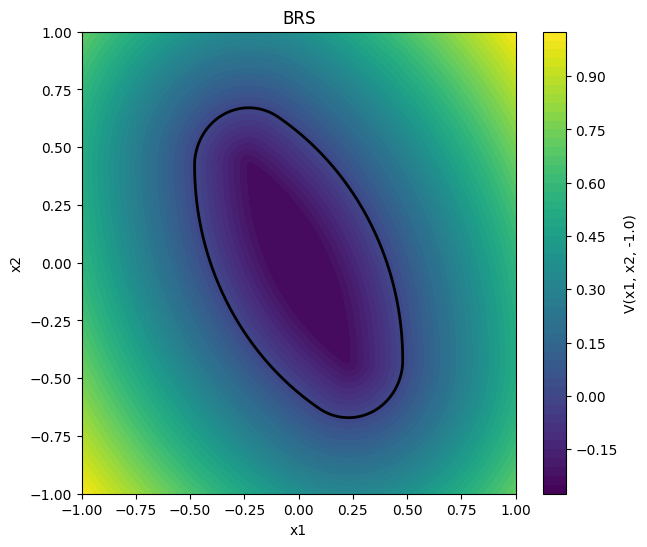

In [112]:
brs = np.array(value_function[-1]) 

plt.figure(figsize=(7,6))
cf = plt.contourf(grid.coordinate_vectors[0], grid.coordinate_vectors[1], brs.T, levels=60)
plt.contour(grid.coordinate_vectors[0], grid.coordinate_vectors[1], brs.T, levels=[0], colors="black", linewidths=2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(cf, label=f"V(x1, x2, {time})")
plt.title(f"BRS")
plt.show()

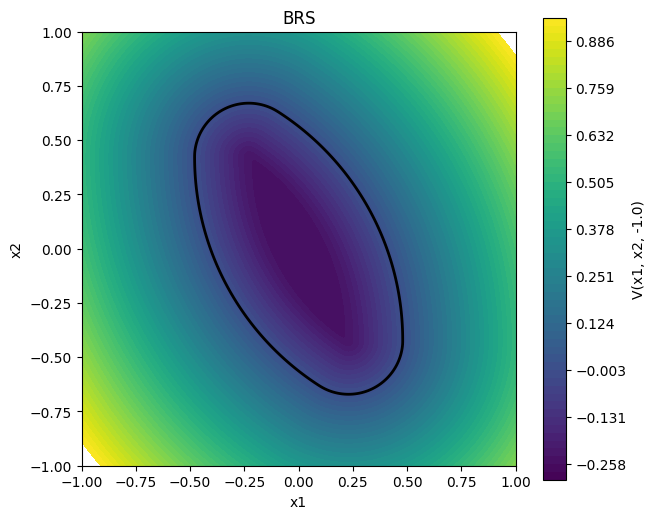

In [115]:
vmin, vmax = -0.30, 0.95
levels = np.linspace(vmin, vmax, 60)

plt.figure(figsize=(7,6))
cf = plt.contourf(
    grid.coordinate_vectors[0],
    grid.coordinate_vectors[1],
    brs.T,
    levels=levels,
    vmin=vmin,
    vmax=vmax
)
plt.contour(
    grid.coordinate_vectors[0],
    grid.coordinate_vectors[1],
    brs.T,
    levels=[0],
    colors="black",
    linewidths=2
)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(cf, label=f"V(x1, x2, {time})")
plt.title("BRS")
plt.gca().set_aspect('equal')
plt.show()
